# CE 639: AI for Civil Engineering
## Lecture 08: Clustering & Unsupervised Learning

**Learning Objectives:**
1. Understand the difference between supervised and unsupervised learning
2. Master K-Means clustering algorithm from scratch
3. Learn hierarchical clustering and dendrogram interpretation
4. Apply various similarity/distance metrics
5. Use elbow method and silhouette score for optimal K selection
6. Detect regimes in time-series data using clustering
7. Apply clustering to Civil Engineering problems

**Topics Covered:**
- K-Means algorithm (initialization, assignment, update)
- K-Means++ for better initialization
- Hierarchical clustering (linkage methods)
- Dendrograms
- Similarity metrics (Euclidean, Manhattan, Cosine, Jaccard)
- Cluster validation (WCSS, Silhouette)
- Regime identification

---

## 1. Setup & Imports

We'll use our custom helper modules for clustering, which implement
all algorithms from scratch for educational purposes.

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("✅ Core imports loaded")

✅ Core imports loaded


In [ ]:
# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab ✓")
except:
    IN_COLAB = False
    print("Running locally ✓")

if IN_COLAB:
    # !git clone https://github.com/dubeysarth/2026_IITGN_CE639
    # %cd 2026_IITGN_CE639
    import os
    subprocess.run(['git', 'clone', 'https://github.com/dubeysarth/2026_IITGN_CE639'])
    os.chdir('2026_IITGN_CE639')

In [2]:
# Import our Lecture 08 utilities
# Run this cell after uploading the utils/Lecture_08 folder to Colab

import sys
sys.path.append('..')  # Add parent directory to path

try:
    from utils.Lecture_08 import (
        # K-Means
        kmeans, kmeans_plusplus_init, compute_wcss, assign_clusters, 
        update_centroids, kmeans_step_by_step,
        # Hierarchical
        agglomerative_clustering, compute_linkage_matrix, cut_dendrogram,
        # Similarity
        euclidean_distance, manhattan_distance, minkowski_distance,
        cosine_similarity, cosine_distance, hamming_distance, jaccard_similarity,
        pairwise_distances,
        # Validation
        silhouette_score, silhouette_samples, elbow_method, find_optimal_k,
        # Regime
        extract_window_features, cluster_based_regime_detection, plot_regime_timeline,
        # Visualizations
        plot_clusters_2d, plot_clusters_3d, plot_dendrogram, plot_elbow,
        plot_silhouette, plot_kmeans_animation, plot_linkage_comparison,
        # Widgets
        kmeans_widget, hierarchical_widget, similarity_widget, elbow_silhouette_widget,
        # CE Examples
        sensor_clustering_data, traffic_flow_data, material_property_data,
        shm_vibration_data, generate_blob_data
    )
    print("✅ Lecture 08 utilities loaded successfully!")
except ImportError as e:
    print(f"⚠️ Import error: {e}")
    print("Make sure utils/Lecture_08 folder is in the same directory")

✅ Lecture 08 utilities loaded successfully!


---
## 2. Supervised vs Unsupervised Learning

### Key Difference

| Aspect | Supervised | Unsupervised |
|--------|------------|--------------|
| Labels | Has target labels (y) | No labels |
| Goal | Predict outcomes | Find patterns/structure |
| Examples | Classification, Regression | Clustering, Dimensionality Reduction |

### When to Use Unsupervised Learning

1. **No labeled data available** - Labeling is expensive or impossible
2. **Exploratory analysis** - Discover hidden patterns
3. **Data preprocessing** - Feature engineering, anomaly detection
4. **Segmentation** - Customer, material, or sensor grouping

### Civil Engineering Applications

- **Material Classification**: Group materials by measured properties
- **Sensor Clustering**: Identify similar sensor behavior in SHM
- **Traffic Regime Detection**: Identify congestion states
- **Anomaly Detection**: Detect structural damage patterns

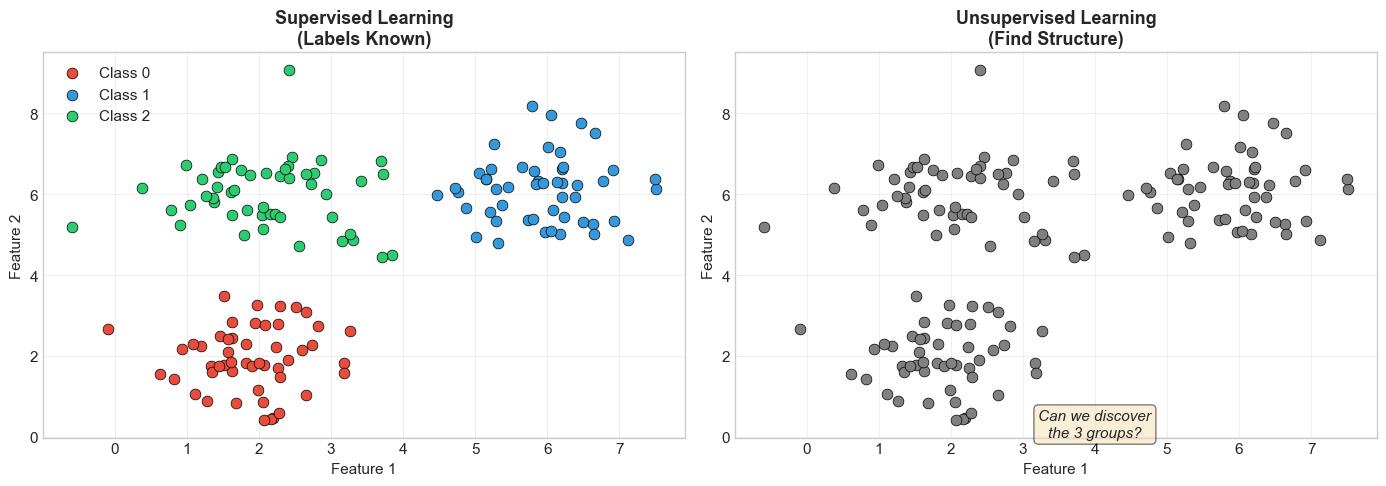

In [3]:
# Visual comparison: Supervised vs Unsupervised
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

np.random.seed(42)
# Generate sample data
X = np.vstack([
    np.random.normal([2, 2], 0.8, (50, 2)),
    np.random.normal([6, 6], 0.8, (50, 2)),
    np.random.normal([2, 6], 0.8, (50, 2))
])
y_true = np.array([0]*50 + [1]*50 + [2]*50)

# Supervised view (with labels)
ax = axes[0]
colors = ['#e74c3c', '#3498db', '#2ecc71']
for i in range(3):
    mask = y_true == i
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[i], s=60, 
               edgecolors='black', linewidth=0.5, label=f'Class {i}')
ax.set_xlabel('Feature 1', fontsize=11)
ax.set_ylabel('Feature 2', fontsize=11)
ax.set_title('Supervised Learning\n(Labels Known)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Unsupervised view (no labels)
ax = axes[1]
ax.scatter(X[:, 0], X[:, 1], c='gray', s=60, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Feature 1', fontsize=11)
ax.set_ylabel('Feature 2', fontsize=11)
ax.set_title('Unsupervised Learning\n(Find Structure)', fontsize=13, fontweight='bold')
ax.text(4, 0, "Can we discover\nthe 3 groups?", fontsize=11, ha='center',
        style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. K-Means Clustering Algorithm

### The Idea
Partition n observations into k clusters where each observation belongs to 
the cluster with the nearest centroid (mean).

### Algorithm Steps

1. **Initialize**: Choose k initial centroids (randomly or using K-Means++)
2. **Assignment**: Assign each point to nearest centroid
3. **Update**: Recompute centroids as mean of assigned points
4. **Repeat**: Until centroids don't move (convergence)

### Mathematical Formulation

**Objective**: Minimize Within-Cluster Sum of Squares (WCSS)

$$WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2$$

Where $\mu_i$ is the centroid of cluster $C_i$.

K-MEANS ALGORITHM STEP-BY-STEP

📊 Dataset: 150 points, 2 features
📍 Number of clusters (K): 3
🔄 Iterations until convergence: 4
📉 Final WCSS: 181.50


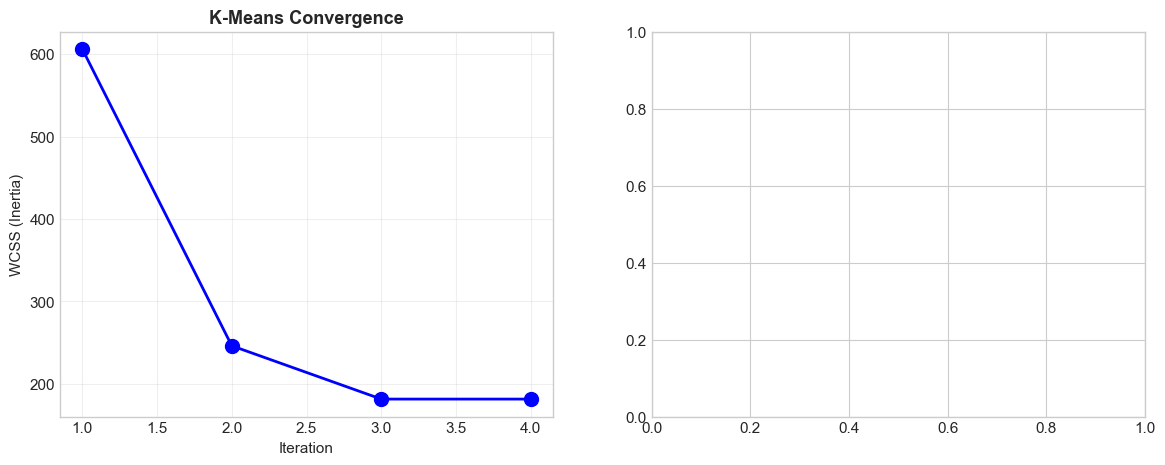

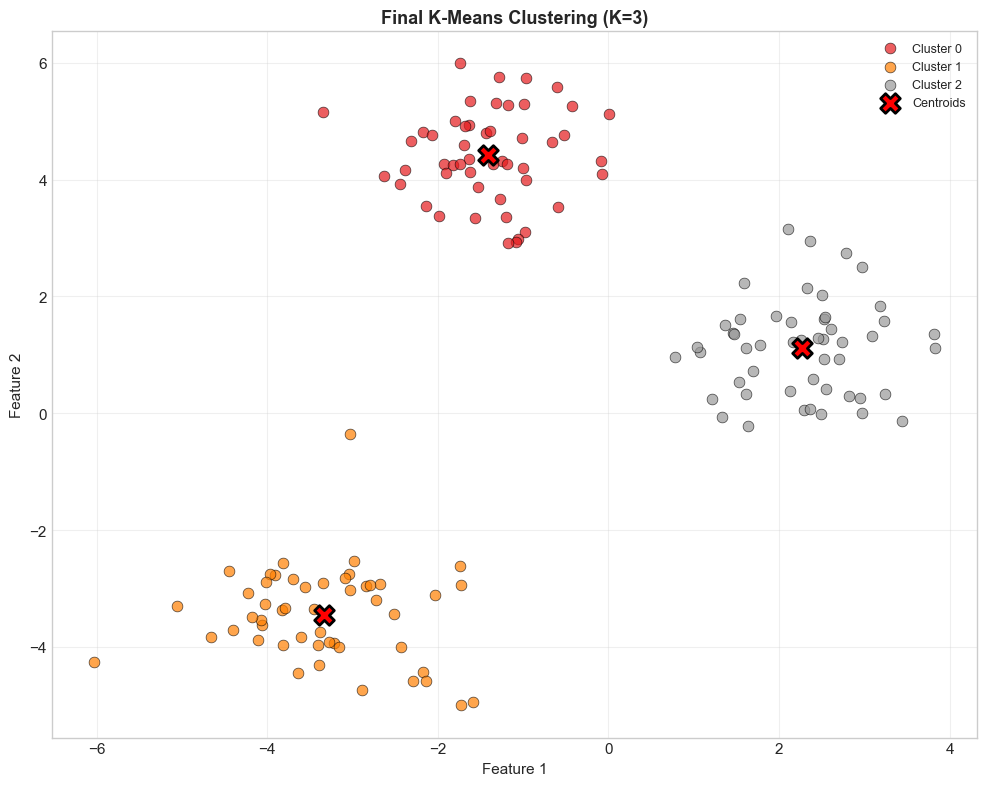

In [4]:
# Show K-Means algorithm step by step

# Generate simple 2D data
np.random.seed(42)
data = generate_blob_data(n_samples=150, n_clusters=3, cluster_std=0.8, random_state=42)
X = data['X']
y_true = data['y_true']

print("=" * 60)
print("K-MEANS ALGORITHM STEP-BY-STEP")
print("=" * 60)

# Run K-Means with our from-scratch implementation
result = kmeans(X, k=3, max_iterations=10, random_state=42)

print(f"\n📊 Dataset: {len(X)} points, 2 features")
print(f"📍 Number of clusters (K): 3")
print(f"🔄 Iterations until convergence: {result['n_iterations']}")
print(f"📉 Final WCSS: {result['wcss']:.2f}")

# Show WCSS progression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WCSS history
ax = axes[0]
ax.plot(range(1, len(result['wcss_history']) + 1), result['wcss_history'], 
        'bo-', linewidth=2, markersize=10)
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('WCSS (Inertia)', fontsize=11)
ax.set_title('K-Means Convergence', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Final clustering
ax = axes[1]
plot_clusters_2d(X, result['labels'], result['centroids'], 
                 title='Final K-Means Clustering (K=3)')
plt.tight_layout()
plt.show()

### Understanding the Steps

Let's visualize what happens at each iteration:

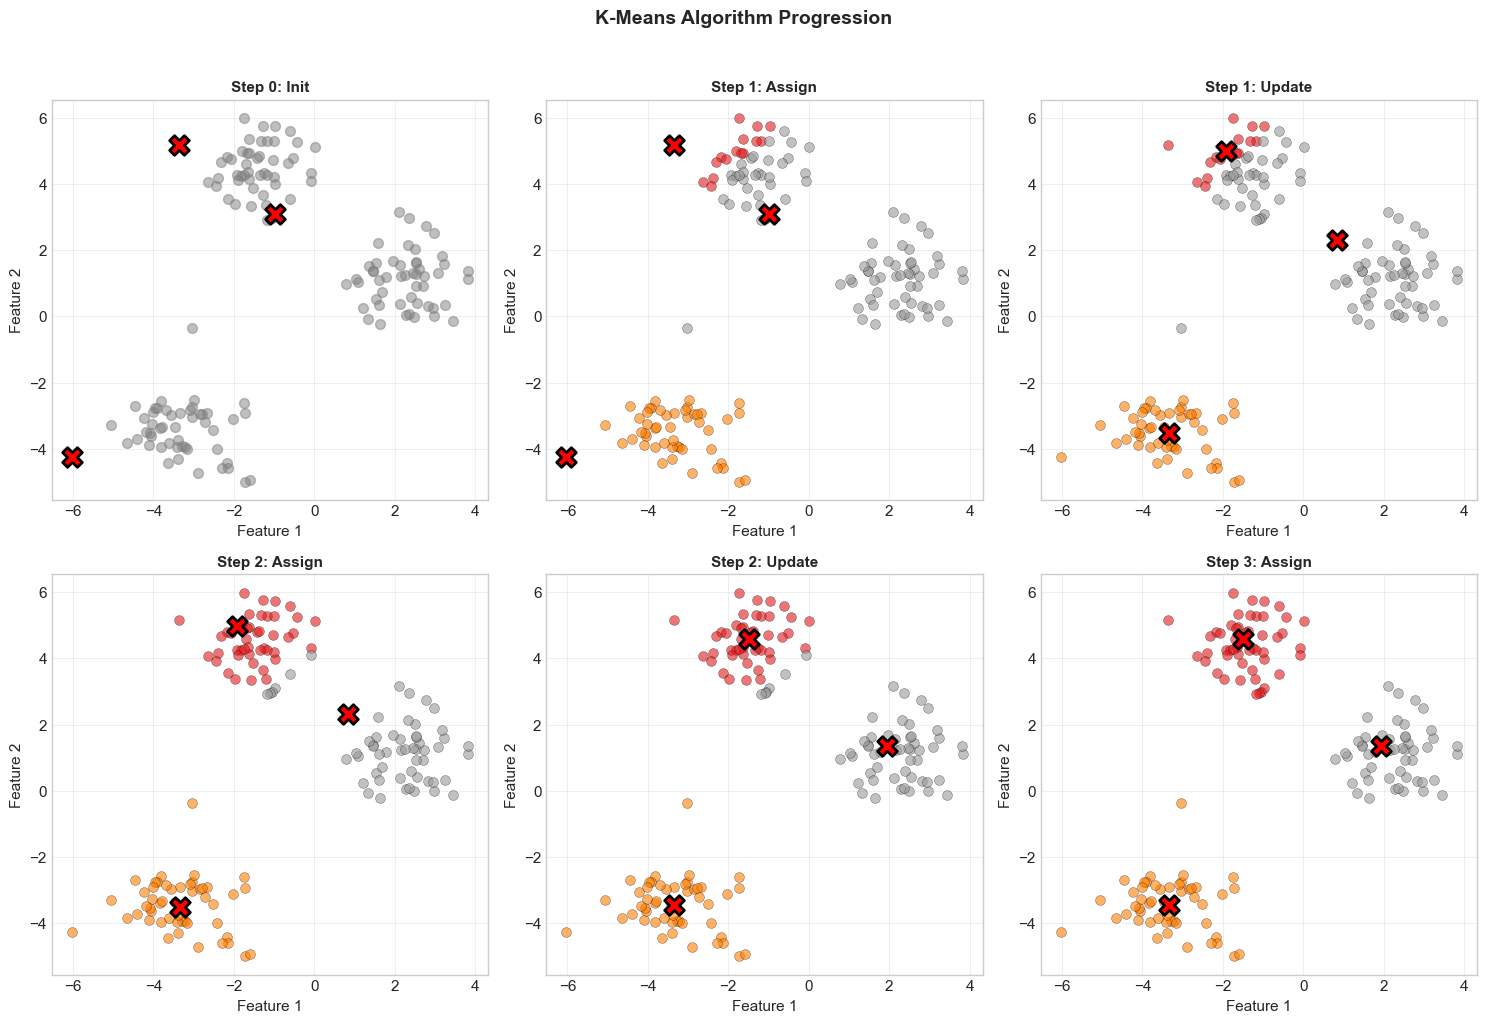

In [5]:
# Animated K-Means visualization (frame by frame)
np.random.seed(42)

# Get step-by-step generator
steps = list(kmeans_step_by_step(X, k=3, random_state=42))

# Show first 4 steps
n_show = min(6, len(steps))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

colors_map = plt.cm.Set1(np.linspace(0, 1, 3))

for idx, (ax, step) in enumerate(zip(axes[:n_show], steps[:n_show])):
    centroids = step['centroids']
    
    if step['labels'] is not None:
        labels = step['labels']
        for k in range(3):
            mask = labels == k
            ax.scatter(X[mask, 0], X[mask, 1], c=[colors_map[k]], 
                      s=50, alpha=0.6, edgecolors='black', linewidth=0.3)
    else:
        ax.scatter(X[:, 0], X[:, 1], c='gray', s=50, alpha=0.5)
    
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', 
              marker='X', s=200, edgecolors='black', linewidth=2, zorder=10)
    
    phase = step['phase'].capitalize()
    ax.set_title(f"Step {step['step']}: {phase}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)

# Hide unused axes
for ax in axes[n_show:]:
    ax.axis('off')

plt.suptitle('K-Means Algorithm Progression', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### K-Means++ Initialization

**Problem with Random Initialization:**
- Poor initial centroids can lead to suboptimal clusters
- More iterations needed to converge
- May get stuck in local minima

**K-Means++ Solution:**
1. Choose first centroid randomly from data points
2. For each subsequent centroid:
   - Compute distance² from each point to nearest existing centroid
   - Select next centroid with probability proportional to distance²
3. This spreads out initial centroids

### Let's Compare:

/var/folders/88/6_ld7h5x3tv_py3zwt7042qr0000gn/T/ipykernel_16087/3606815276.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([wcss_random, wcss_kpp], labels=['Random', 'K-Means++'])


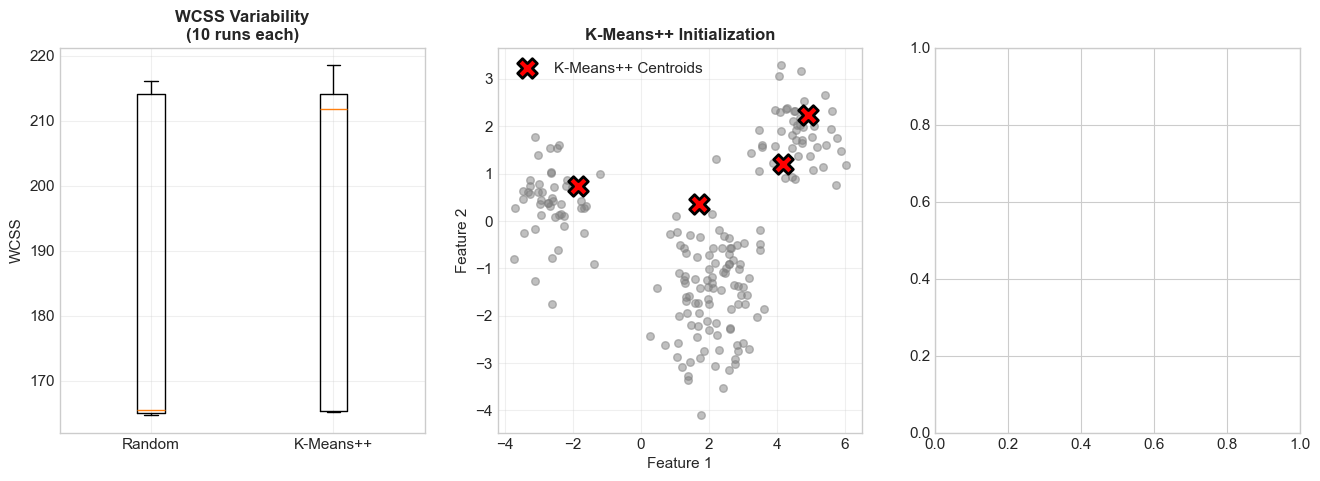

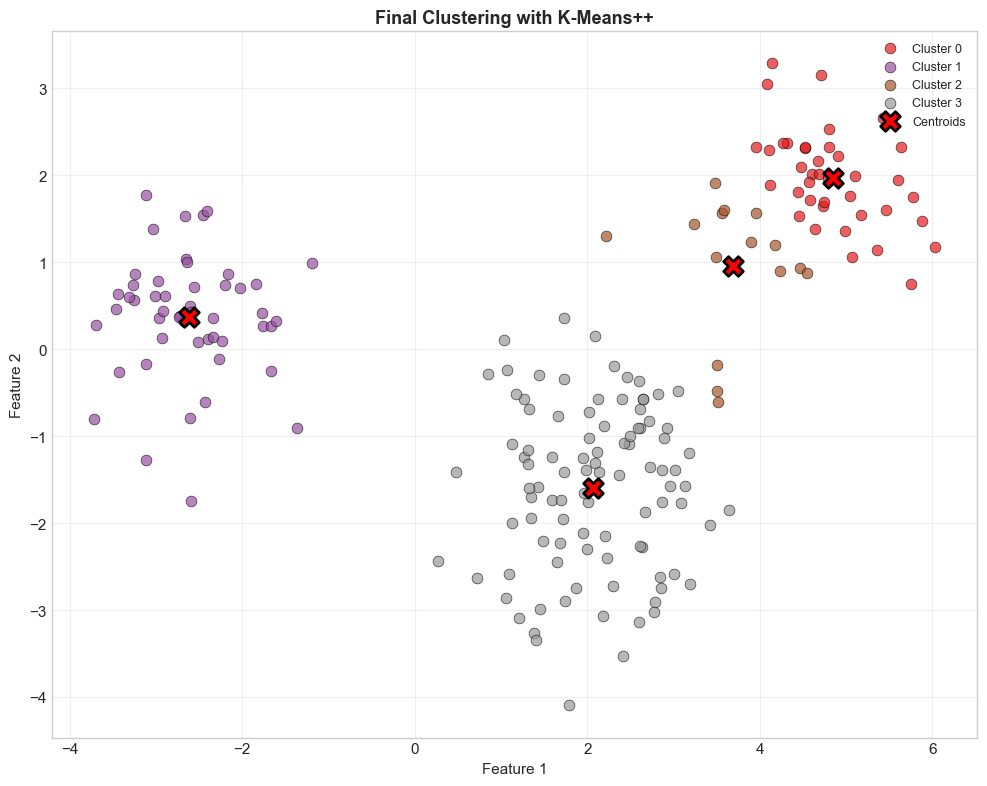

Random Init - WCSS: 184.97 ± 24.29
K-Means++   - WCSS: 194.61 ± 24.01


In [6]:
# Compare random vs K-Means++ initialization
np.random.seed(123)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Data
X_test = generate_blob_data(n_samples=200, n_clusters=4, cluster_std=0.7, random_state=123)['X']

# Random initialization (multiple runs)
wcss_random = []
for _ in range(10):
    result_random = kmeans(X_test, k=4, init='random')
    wcss_random.append(result_random['wcss'])

# K-Means++ (multiple runs)
wcss_kpp = []
for _ in range(10):
    result_kpp = kmeans(X_test, k=4, init='kmeans++')
    wcss_kpp.append(result_kpp['wcss'])

# Plot comparison
ax = axes[0]
ax.boxplot([wcss_random, wcss_kpp], labels=['Random', 'K-Means++'])
ax.set_ylabel('WCSS', fontsize=11)
ax.set_title('WCSS Variability\n(10 runs each)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Show K-Means++ initialization
centroids_kpp = kmeans_plusplus_init(X_test, k=4, random_state=42)

ax = axes[1]
ax.scatter(X_test[:, 0], X_test[:, 1], c='gray', s=30, alpha=0.5)
ax.scatter(centroids_kpp[:, 0], centroids_kpp[:, 1], c='red', 
          marker='X', s=200, edgecolors='black', linewidth=2, 
          label='K-Means++ Centroids')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('K-Means++ Initialization', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Final result with K-Means++
result_final = kmeans(X_test, k=4, init='kmeans++', random_state=42)
ax = axes[2]
plot_clusters_2d(X_test, result_final['labels'], result_final['centroids'],
                 title='Final Clustering with K-Means++')

plt.tight_layout()
plt.show()

print(f"Random Init - WCSS: {np.mean(wcss_random):.2f} ± {np.std(wcss_random):.2f}")
print(f"K-Means++   - WCSS: {np.mean(wcss_kpp):.2f} ± {np.std(wcss_kpp):.2f}")

---
## 4. Interactive K-Means Exploration

Use the widget below to explore how K-Means behaves with different parameters:

In [7]:
# Interactive K-Means widget
# Uncomment to run in Colab/Jupyter
# kmeans_widget()

# Static demonstration for non-interactive environments
print("📊 K-Means Interactive Explorer")
print("=" * 50)
print("Parameters to explore:")
print("  - K: Number of clusters (2-8)")
print("  - N Samples: Dataset size")
print("  - Spread: Cluster tightness")
print("  - Init: 'kmeans++' vs 'random'")
print("\n🔧 Run kmeans_widget() in Jupyter/Colab for interactivity")

📊 K-Means Interactive Explorer
Parameters to explore:
  - K: Number of clusters (2-8)
  - N Samples: Dataset size
  - Spread: Cluster tightness
  - Init: 'kmeans++' vs 'random'

🔧 Run kmeans_widget() in Jupyter/Colab for interactivity


---
## 5. Choosing K: Elbow Method & Silhouette Analysis

### The Challenge
K-Means requires K as input, but how do we know the "right" K?

### Method 1: Elbow Method (WCSS)
- Plot WCSS vs K
- Look for the "elbow" where WCSS decrease slows down
- Beyond the elbow, adding clusters gives diminishing returns

### Method 2: Silhouette Score
- Measures how well each point fits its cluster vs other clusters
- Range: [-1, 1], higher is better
- Choose K that maximizes average silhouette

### Silhouette Coefficient Formula

For each point $i$:
- $a_i$ = average distance to points in same cluster
- $b_i$ = minimum average distance to points in nearest other cluster

$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)}$$

**Interpretation:**
- $s_i \approx 1$: Well clustered, far from others
- $s_i \approx 0$: On border between clusters
- $s_i < 0$: Likely in wrong cluster

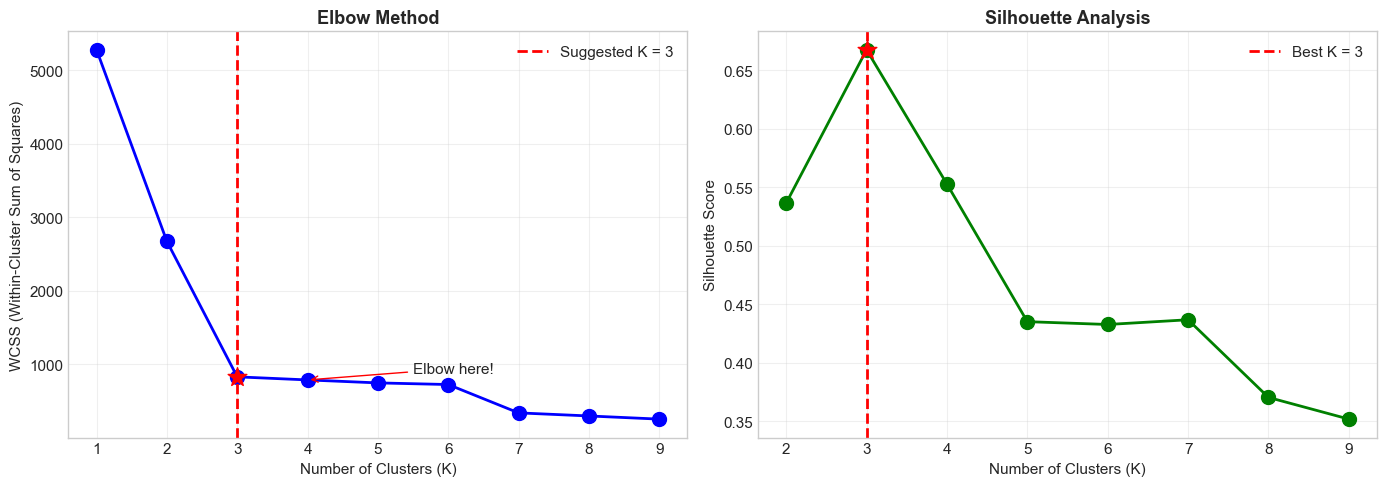

🎯 Elbow Method suggests K = 3
🎯 Silhouette Analysis best K = 3
✅ True number of clusters = 4


In [8]:
# Elbow method demonstration
np.random.seed(42)

# Generate data with 4 true clusters
X_elbow = generate_blob_data(n_samples=300, n_clusters=4, cluster_std=0.9, random_state=42)['X']

# Compute elbow
elbow_result = elbow_method(X_elbow, k_range=range(1, 10), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax = axes[0]
ax.plot(elbow_result['k_values'], elbow_result['wcss'], 'bo-', linewidth=2, markersize=10)
ax.axvline(elbow_result['optimal_k'], color='red', linestyle='--', 
          linewidth=2, label=f"Suggested K = {elbow_result['optimal_k']}")
ax.scatter([elbow_result['optimal_k']], 
          [elbow_result['wcss'][elbow_result['k_values'].index(elbow_result['optimal_k'])]],
          c='red', s=200, marker='*', zorder=10)
ax.set_xlabel('Number of Clusters (K)', fontsize=11)
ax.set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=11)
ax.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax.set_xticks(elbow_result['k_values'])
ax.legend()
ax.grid(True, alpha=0.3)

# Annotate elbow
ax.annotate('Elbow here!', xy=(4, elbow_result['wcss'][3]), 
            xytext=(5.5, elbow_result['wcss'][3] + 100),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='red'))

# Silhouette scores
silhouette_scores = []
for k in range(2, 10):
    result = kmeans(X_elbow, k=k, random_state=42)
    sil = silhouette_score(X_elbow, result['labels'])
    silhouette_scores.append(sil)

ax = axes[1]
ax.plot(range(2, 10), silhouette_scores, 'go-', linewidth=2, markersize=10)
best_k = np.argmax(silhouette_scores) + 2
ax.axvline(best_k, color='red', linestyle='--', linewidth=2, label=f'Best K = {best_k}')
ax.scatter([best_k], [max(silhouette_scores)], c='red', s=200, marker='*', zorder=10)
ax.set_xlabel('Number of Clusters (K)', fontsize=11)
ax.set_ylabel('Silhouette Score', fontsize=11)
ax.set_title('Silhouette Analysis', fontsize=13, fontweight='bold')
ax.set_xticks(range(2, 10))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"🎯 Elbow Method suggests K = {elbow_result['optimal_k']}")
print(f"🎯 Silhouette Analysis best K = {best_k}")
print(f"✅ True number of clusters = 4")

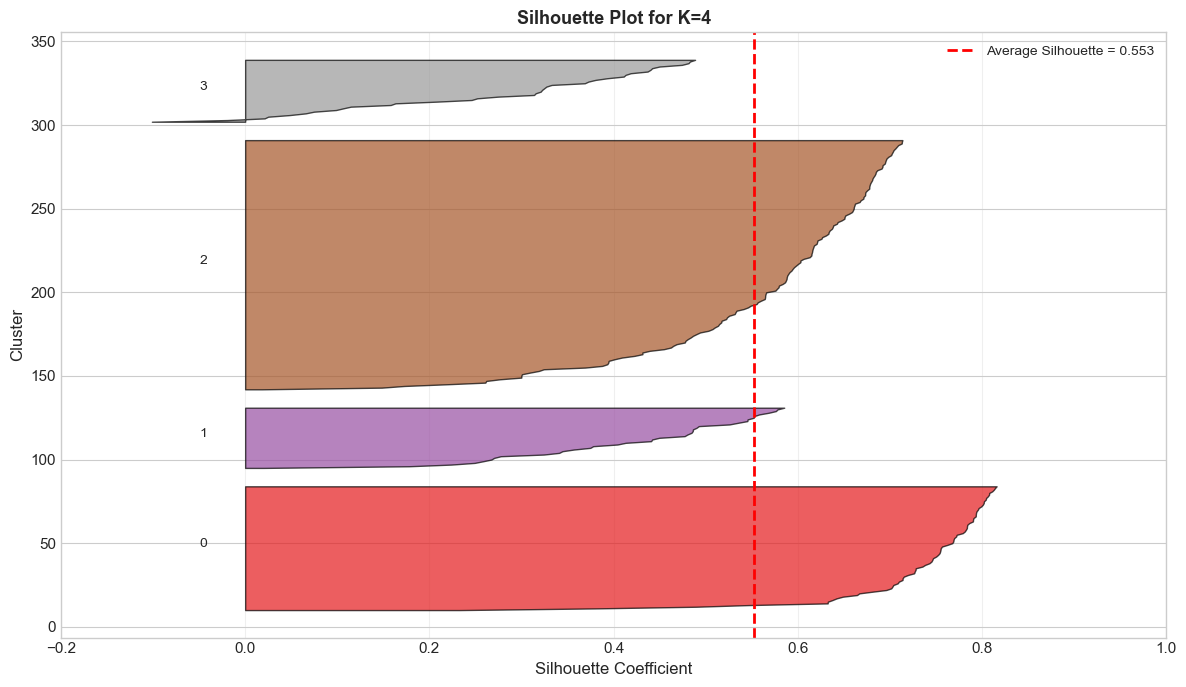

In [9]:
# Silhouette plot for K=4
result_k4 = kmeans(X_elbow, k=4, random_state=42)
fig, ax = plot_silhouette(X_elbow, result_k4['labels'], 
                          title='Silhouette Plot for K=4')
plt.tight_layout()
plt.show()

### Interactive Elbow/Silhouette Exploration

In [10]:
# Interactive widget for exploring optimal K
# Uncomment to run:
# elbow_silhouette_widget()

print("🔧 Run elbow_silhouette_widget() for interactive exploration")
print("   - Adjust true K and see how methods detect it")
print("   - Change cluster spread to see impact on detection")

🔧 Run elbow_silhouette_widget() for interactive exploration
   - Adjust true K and see how methods detect it
   - Change cluster spread to see impact on detection


---
## 6. Similarity Metrics

### Why Metrics Matter
The choice of distance metric significantly affects clustering results.
Different metrics capture different notions of "similarity."

### Common Metrics

| Metric | Formula | Best For |
|--------|---------|----------|
| Euclidean | $\sqrt{\sum (x_i - y_i)^2}$ | General, continuous |
| Manhattan | $\sum |x_i - y_i|$ | Grid-like, robust |
| Cosine | $\frac{x \cdot y}{\|x\|\|y\|}$ | Text, high-dim |
| Jaccard | $\frac{|A \cap B|}{|A \cup B|}$ | Sets, binary |

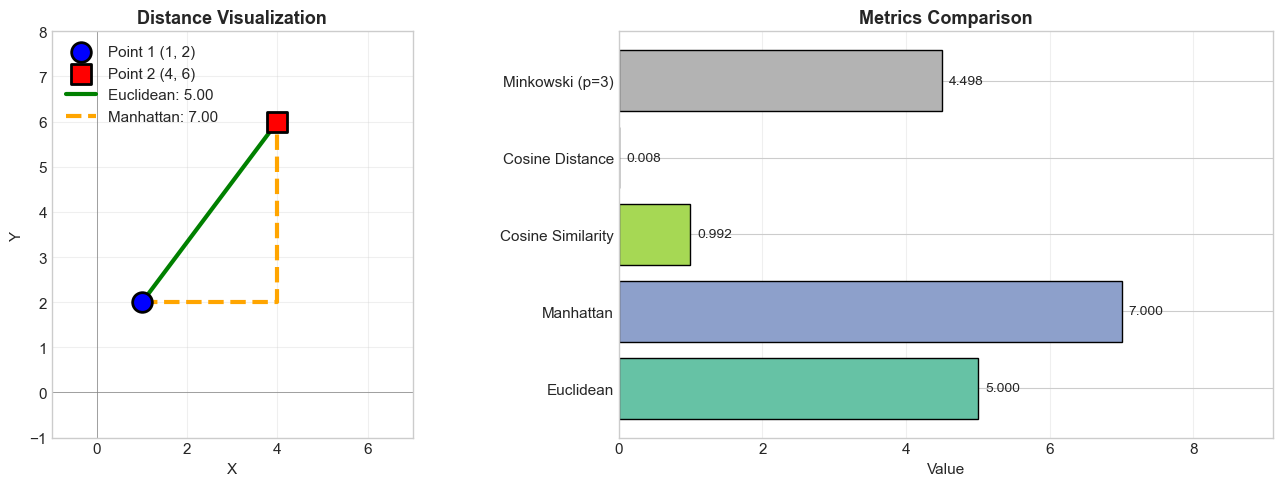

In [11]:
# Compare distance metrics visually
from utils.Lecture_08.similarity_metrics import compare_metrics

# Two example points
p1 = np.array([1, 2])
p2 = np.array([4, 6])

metrics = compare_metrics(p1, p2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visual representation
ax = axes[0]
ax.scatter(*p1, s=200, c='blue', marker='o', edgecolors='black', 
          linewidths=2, label=f'Point 1 ({p1[0]}, {p1[1]})', zorder=5)
ax.scatter(*p2, s=200, c='red', marker='s', edgecolors='black', 
          linewidths=2, label=f'Point 2 ({p2[0]}, {p2[1]})', zorder=5)

# Euclidean (straight line)
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g-', linewidth=3, 
       label=f'Euclidean: {metrics["Euclidean"]:.2f}')

# Manhattan (L-shape)
ax.plot([p1[0], p2[0], p2[0]], [p1[1], p1[1], p2[1]], 'orange', 
       linewidth=3, linestyle='--', label=f'Manhattan: {metrics["Manhattan"]:.2f}')

ax.set_xlim(-1, 7)
ax.set_ylim(-1, 8)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('X', fontsize=11)
ax.set_ylabel('Y', fontsize=11)
ax.set_title('Distance Visualization', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Bar chart of metrics
ax = axes[1]
metric_names = list(metrics.keys())
metric_values = list(metrics.values())
colors = plt.cm.Set2(np.linspace(0, 1, len(metrics)))
bars = ax.barh(metric_names, metric_values, color=colors, edgecolor='black')

for bar, val in zip(bars, metric_values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_xlabel('Value', fontsize=11)
ax.set_title('Metrics Comparison', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(metric_values) * 1.3)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

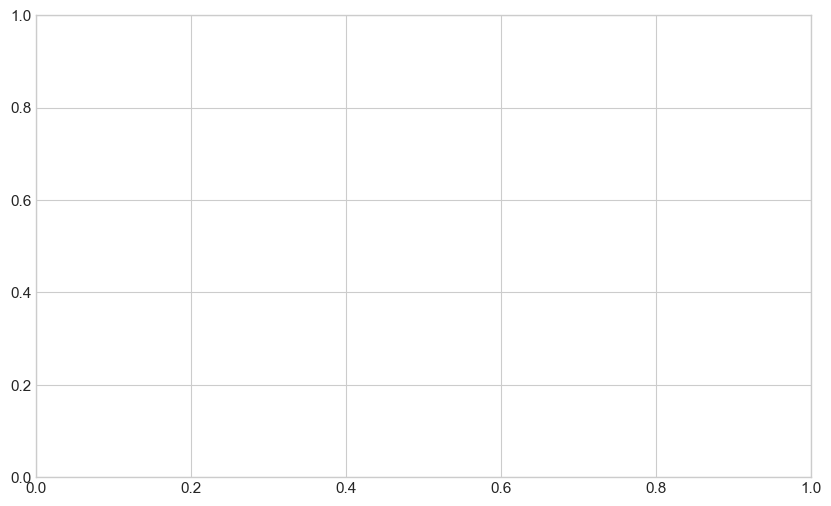

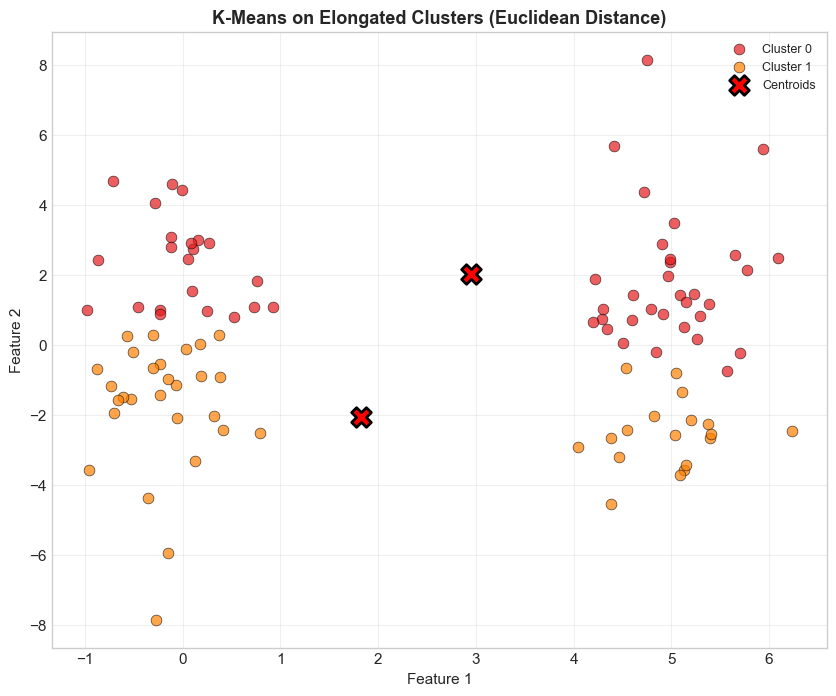

📌 Note: K-Means uses Euclidean distance by default
📌 For elongated clusters, consider using Gaussian Mixture Models
📌 Or transform features to have similar scales


In [12]:
# Show effect of metric choice on clustering
np.random.seed(42)

# Create elongated clusters (where metric matters)
n = 50
X_elongated = np.vstack([
    np.column_stack([np.random.normal(0, 0.5, n), np.random.normal(0, 3, n)]),
    np.column_stack([np.random.normal(5, 0.5, n), np.random.normal(0, 3, n)])
])

# Euclidean K-Means
result_euc = kmeans(X_elongated, k=2, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
plot_clusters_2d(X_elongated, result_euc['labels'], result_euc['centroids'],
                 title='K-Means on Elongated Clusters (Euclidean Distance)')
plt.show()

print("📌 Note: K-Means uses Euclidean distance by default")
print("📌 For elongated clusters, consider using Gaussian Mixture Models")
print("📌 Or transform features to have similar scales")

### Interactive Similarity Exploration

In [13]:
# Interactive similarity widget
# similarity_widget()
print("🔧 Run similarity_widget() to interactively compare distances")

🔧 Run similarity_widget() to interactively compare distances


---
## 7. Hierarchical Clustering

### The Idea
Build a hierarchy of clusters instead of flat partition.
Two approaches:
- **Agglomerative (bottom-up)**: Start with each point as cluster, merge
- **Divisive (top-down)**: Start with one cluster, split

### Agglomerative Algorithm

1. Start: Each point is its own cluster
2. Find two closest clusters (using linkage criterion)
3. Merge them into one cluster
4. Repeat until one cluster remains
5. Show result as a **dendrogram** (tree diagram)

### Linkage Methods

| Method | Distance Between Clusters |
|--------|---------------------------|
| Single | Minimum pairwise distance |
| Complete | Maximum pairwise distance |
| Average | Average pairwise distance |
| Ward | Increase in WCSS when merged |

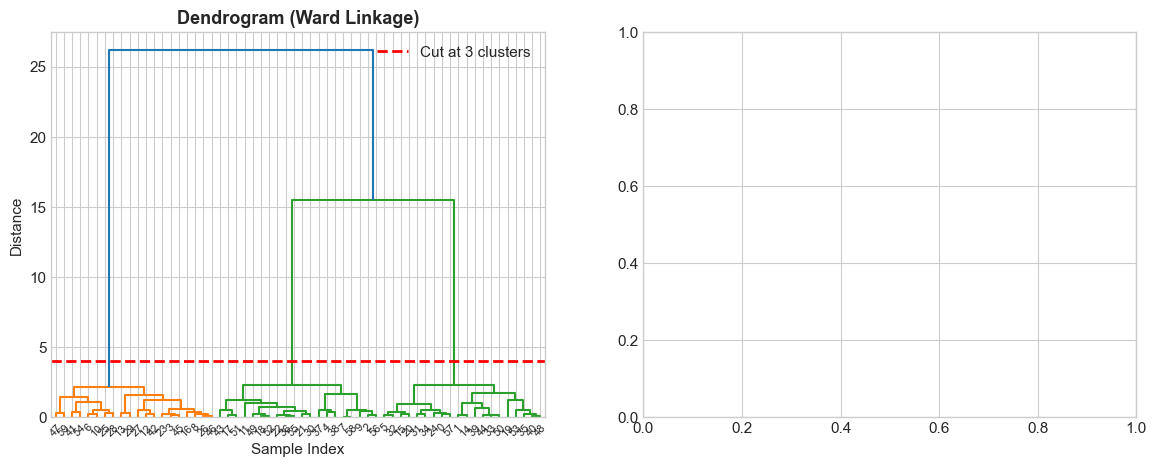

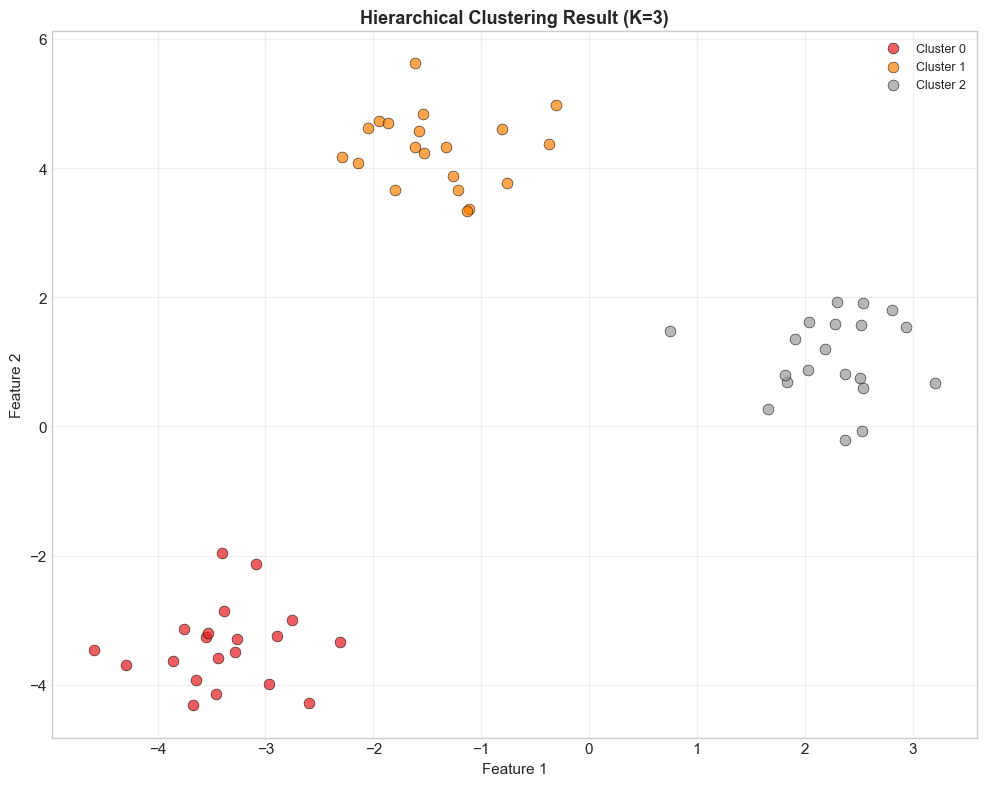

In [14]:
# Demonstrate hierarchical clustering
np.random.seed(42)

# Generate data
X_hier = generate_blob_data(n_samples=60, n_clusters=3, cluster_std=0.6, random_state=42)['X']

# Apply hierarchical clustering
hier_result = agglomerative_clustering(X_hier, n_clusters=3, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dendrogram
ax = axes[0]
try:
    from scipy.cluster.hierarchy import dendrogram as scipy_dendrogram
    linkage_matrix = compute_linkage_matrix(X_hier, method='ward')
    scipy_dendrogram(linkage_matrix, ax=ax, leaf_rotation=45, leaf_font_size=8)
    ax.set_xlabel('Sample Index', fontsize=11)
    ax.set_ylabel('Distance', fontsize=11)
    ax.set_title('Dendrogram (Ward Linkage)', fontsize=13, fontweight='bold')
    ax.axhline(y=4, color='r', linestyle='--', linewidth=2, label='Cut at 3 clusters')
    ax.legend()
except ImportError:
    # Fallback without scipy
    linkage_matrix = compute_linkage_matrix(X_hier, method='ward')
    heights = linkage_matrix[:, 2]
    ax.bar(range(len(heights)), heights, color='steelblue', alpha=0.7)
    ax.set_xlabel('Merge Step', fontsize=11)
    ax.set_ylabel('Linkage Distance', fontsize=11)
    ax.set_title('Merge Distances (Ward)', fontsize=13, fontweight='bold')

# Clustering result
ax = axes[1]
plot_clusters_2d(X_hier, hier_result['labels'], centroids=None,
                 title='Hierarchical Clustering Result (K=3)')

plt.tight_layout()
plt.show()

### Comparing Linkage Methods

Different linkage methods produce different cluster shapes:

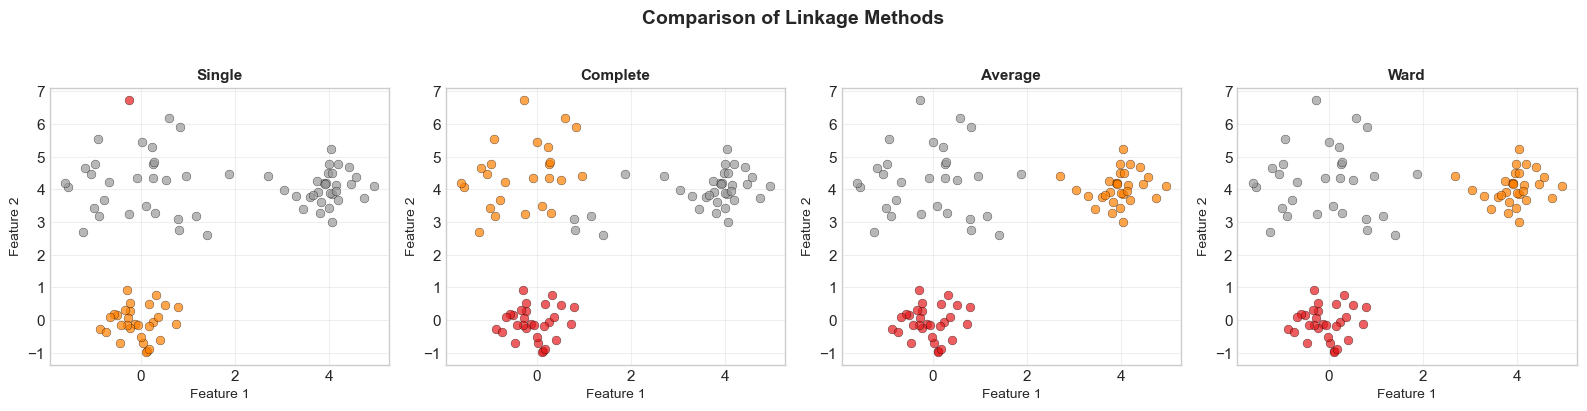


📊 Linkage Method Characteristics:
  - Single: Can handle elongated clusters, but sensitive to noise
  - Complete: Produces compact clusters, sensitive to outliers
  - Average: Balance between single and complete
  - Ward: Minimizes variance, produces spherical clusters (like K-Means)


In [15]:
# Compare linkage methods
np.random.seed(42)

# Create data with different shapes
X_link = np.vstack([
    np.random.normal([0, 0], 0.5, (30, 2)),
    np.random.normal([4, 4], 0.5, (30, 2)),
    np.random.normal([0, 4], 1.0, (30, 2))
])

methods = ['single', 'complete', 'average', 'ward']
labels_dict = {}

for method in methods:
    result = agglomerative_clustering(X_link, n_clusters=3, method=method)
    labels_dict[method.capitalize()] = result['labels']

fig, axes = plot_linkage_comparison(X_link, labels_dict, 
                                    title='Comparison of Linkage Methods')
plt.tight_layout()
plt.show()

print("\n📊 Linkage Method Characteristics:")
print("  - Single: Can handle elongated clusters, but sensitive to noise")
print("  - Complete: Produces compact clusters, sensitive to outliers")
print("  - Average: Balance between single and complete")
print("  - Ward: Minimizes variance, produces spherical clusters (like K-Means)")

### Interactive Hierarchical Exploration

In [16]:
# Interactive hierarchical widget
# hierarchical_widget()
print("🔧 Run hierarchical_widget() for interactive exploration")

🔧 Run hierarchical_widget() for interactive exploration


---
## 8. Regime Identification in Time Series

### The Concept
Many Civil Engineering systems operate in distinct "regimes" or states:
- Traffic flow: Free, Synchronized, Congested
- Structures: Normal, Transitional, Damaged
- Weather: Calm, Storm, Hurricane

### Clustering Approach
1. **Extract features** from sliding windows
2. **Cluster** the windows
3. Each cluster = a regime

### Window Features
- Mean, Standard Deviation
- Min, Max, Range
- Frequency content (optional)

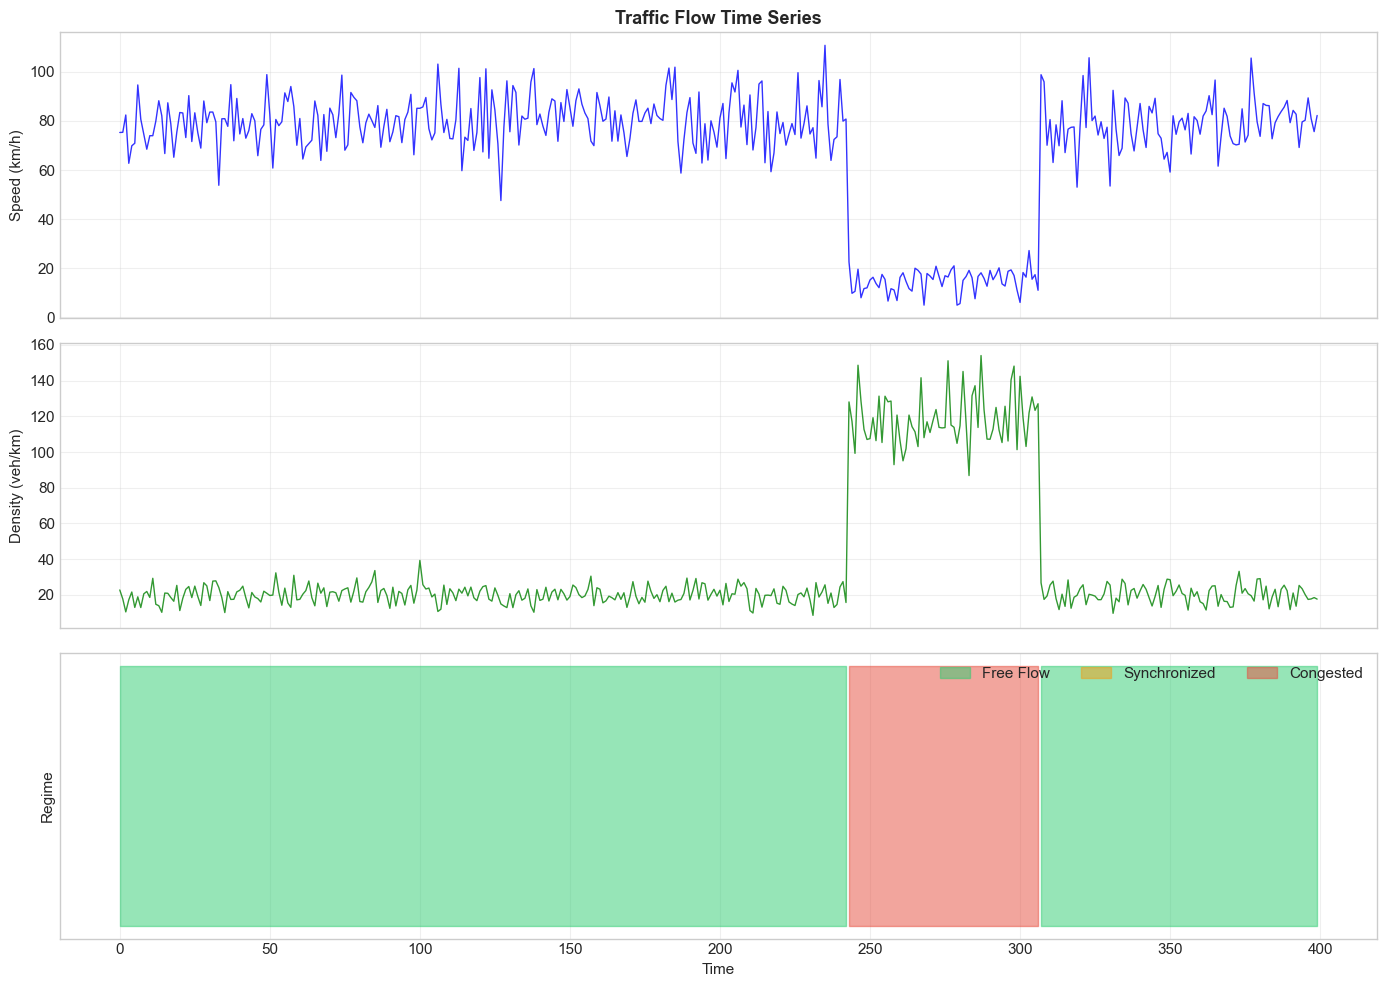

In [17]:
# Generate traffic flow data with regimes
np.random.seed(42)
traffic_data = traffic_flow_data(n_timesteps=400, n_regimes=3, random_state=42)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Speed
ax = axes[0]
ax.plot(traffic_data['time'], traffic_data['speed'], 'b-', linewidth=1, alpha=0.8)
ax.set_ylabel('Speed (km/h)', fontsize=11)
ax.set_title('Traffic Flow Time Series', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Density
ax = axes[1]
ax.plot(traffic_data['time'], traffic_data['density'], 'g-', linewidth=1, alpha=0.8)
ax.set_ylabel('Density (veh/km)', fontsize=11)
ax.grid(True, alpha=0.3)

# True regimes
ax = axes[2]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
for i, name in enumerate(traffic_data['regime_names']):
    mask = traffic_data['true_regimes'] == i
    ax.fill_between(traffic_data['time'], 0, 1, where=mask, 
                   alpha=0.5, color=colors[i], label=name)
ax.set_ylabel('Regime', fontsize=11)
ax.set_xlabel('Time', fontsize=11)
ax.legend(loc='upper right', ncol=3)
ax.set_yticks([])
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

Extracted 386 windows with 5 features each
Features: ['mean', 'std', 'min', 'max', 'range']


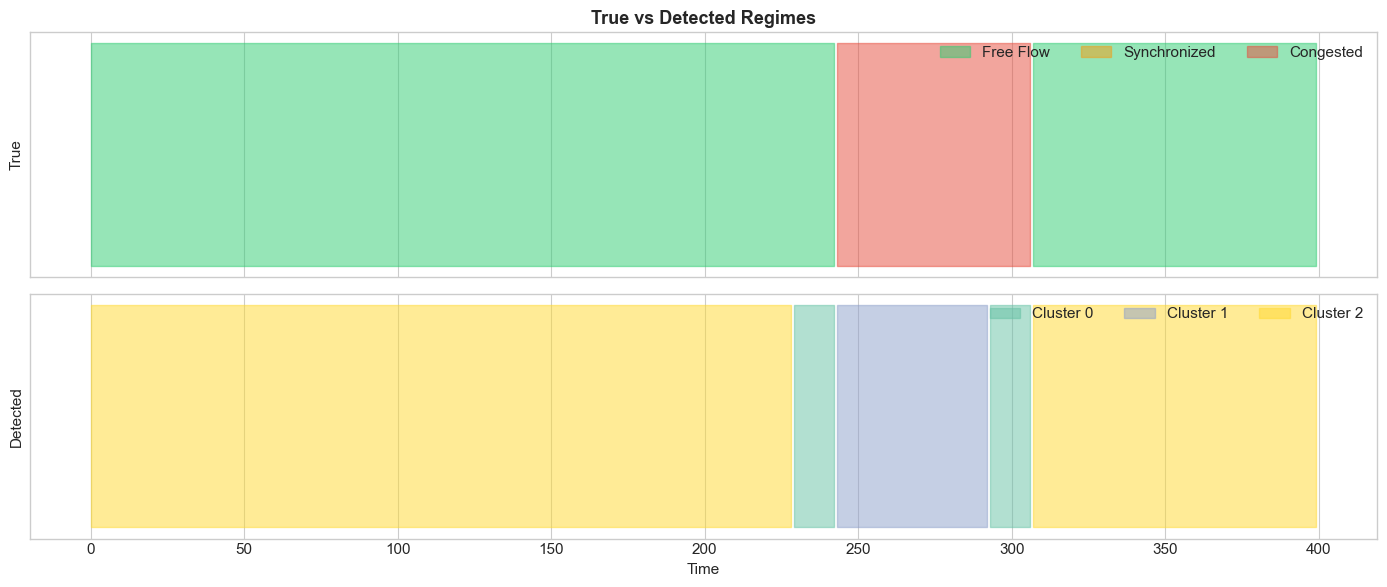

📊 Note: Cluster labels may not match regime labels (permutation)
🎯 Key insight: Clustering successfully identifies distinct patterns!


In [18]:
# Apply clustering-based regime detection
speed_series = traffic_data['speed']

# Extract window features
features = extract_window_features(speed_series, window_size=15, features='all')
print(f"Extracted {features['features'].shape[0]} windows with {features['features'].shape[1]} features each")
print(f"Features: {features['feature_names']}")

# Cluster windows
regime_result = cluster_based_regime_detection(speed_series, n_regimes=3, 
                                               window_size=15, random_state=42)

# Map back to time series
from utils.Lecture_08.regime_identification import map_regimes_to_time
detected_regimes = map_regimes_to_time(regime_result['regime_labels'], 
                                       regime_result['window_indices'],
                                       len(speed_series))

# Compare detected vs true
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax = axes[0]
ax.set_title('True vs Detected Regimes', fontsize=13, fontweight='bold')
for i, name in enumerate(traffic_data['regime_names']):
    mask = traffic_data['true_regimes'] == i
    ax.fill_between(traffic_data['time'], 0, 1, where=mask, 
                   alpha=0.5, color=colors[i], label=name)
ax.set_ylabel('True', fontsize=11)
ax.legend(loc='upper right', ncol=3)
ax.set_yticks([])

ax = axes[1]
for i in range(3):
    mask = detected_regimes == i
    ax.fill_between(traffic_data['time'], 0, 1, where=mask, 
                   alpha=0.5, color=plt.cm.Set2(i / 3), label=f'Cluster {i}')
ax.set_ylabel('Detected', fontsize=11)
ax.set_xlabel('Time', fontsize=11)
ax.legend(loc='upper right', ncol=3)
ax.set_yticks([])

plt.tight_layout()
plt.show()

print("📊 Note: Cluster labels may not match regime labels (permutation)")
print("🎯 Key insight: Clustering successfully identifies distinct patterns!")

---
## 9. Civil Engineering Application: Sensor Clustering

### Problem
Group structural health monitoring sensors based on their behavior patterns
to identify:
- Normal operation zones
- High-stress areas
- Potential anomalies

### Dataset Features
- Average reading magnitude
- Variability (standard deviation)
- Response time

📡 80 sensors with 3 features each
   Features: ['avg_reading', 'variability', 'response_time']

🎯 Optimal K (silhouette): 3


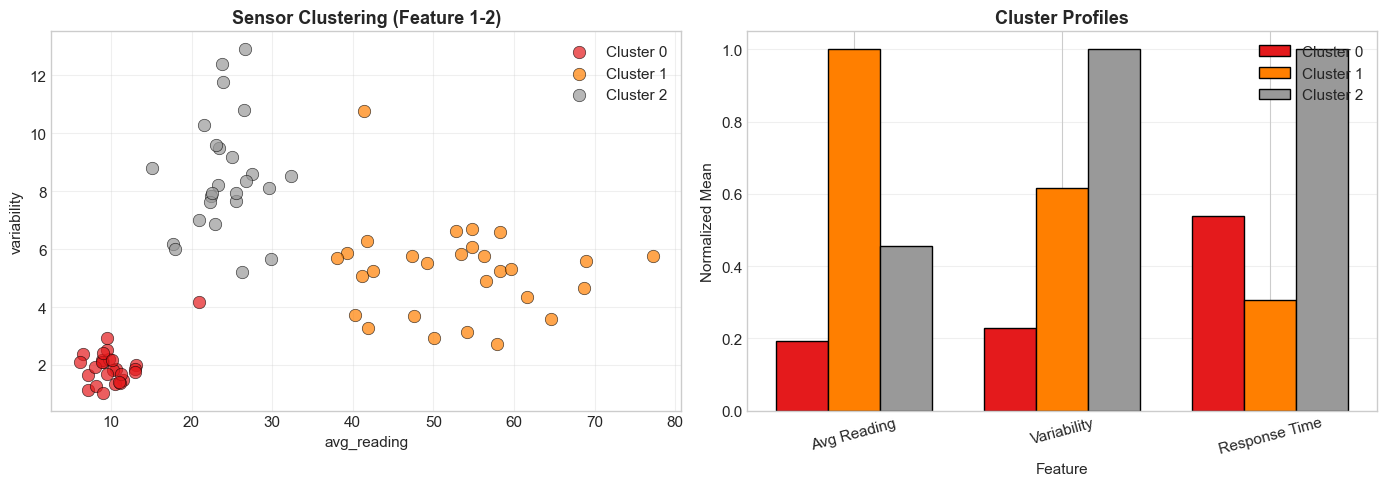

In [19]:
# Load sensor clustering data
sensor_data = sensor_clustering_data(n_sensors=80, n_clusters=3, random_state=42)
X_sensors = sensor_data['X']
y_true_sensors = sensor_data['y_true']

print(f"📡 {len(X_sensors)} sensors with {X_sensors.shape[1]} features each")
print(f"   Features: {sensor_data['feature_names']}")

# Normalize features
X_norm = (X_sensors - X_sensors.mean(axis=0)) / X_sensors.std(axis=0)

# Find optimal K
optimal = find_optimal_k(X_norm, k_range=range(2, 7), method='silhouette', random_state=42)
print(f"\n🎯 Optimal K (silhouette): {optimal['optimal_k']}")

# Cluster sensors
sensor_result = kmeans(X_norm, k=optimal['optimal_k'], random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 2D projection (first two features)
ax = axes[0]
colors = plt.cm.Set1(np.linspace(0, 1, optimal['optimal_k']))
for k in range(optimal['optimal_k']):
    mask = sensor_result['labels'] == k
    ax.scatter(X_sensors[mask, 0], X_sensors[mask, 1], c=[colors[k]], 
              s=80, alpha=0.7, edgecolors='black', linewidths=0.5,
              label=f'Cluster {k}')
ax.set_xlabel(sensor_data['feature_names'][0], fontsize=11)
ax.set_ylabel(sensor_data['feature_names'][1], fontsize=11)
ax.set_title('Sensor Clustering (Feature 1-2)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Cluster profiles
ax = axes[1]
cluster_means = []
for k in range(optimal['optimal_k']):
    mask = sensor_result['labels'] == k
    cluster_means.append(X_sensors[mask].mean(axis=0))

cluster_means = np.array(cluster_means)
x_pos = np.arange(len(sensor_data['feature_names']))
width = 0.25

for k in range(optimal['optimal_k']):
    ax.bar(x_pos + k*width, cluster_means[k] / cluster_means.max(axis=0), 
          width, label=f'Cluster {k}', color=colors[k], edgecolor='black')

ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Normalized Mean', fontsize=11)
ax.set_title('Cluster Profiles', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos + width)
ax.set_xticklabels(['Avg Reading', 'Variability', 'Response Time'], rotation=15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Interpretation of Sensor Clusters

Based on the cluster profiles:
- **Cluster 0** (Low reading, low variability): Normal operation sensors
- **Cluster 1** (High reading, moderate variability): Stressed zone sensors
- **Cluster 2** (Medium reading, high variability): Active/dynamic zone

This information can guide:
- Maintenance priorities
- Sensor placement optimization
- Anomaly detection thresholds

---
## 10. Civil Engineering Application: Material Classification

### Problem
Classify construction materials based on measured mechanical properties
without prior labels (quality control, unknown samples).

### Dataset Features
- Compressive strength (MPa)
- Tensile strength (MPa)
- Elastic modulus (GPa)
- Density (kg/m³)

🧱 100 material samples
   Features: ['compressive_strength_MPa', 'tensile_strength_MPa', 'elastic_modulus_GPa', 'density_kg_m3']
   True materials: ['Concrete', 'Steel', 'Aluminum', 'Wood']

🎯 Clustering accuracy (best mapping): 64.0%


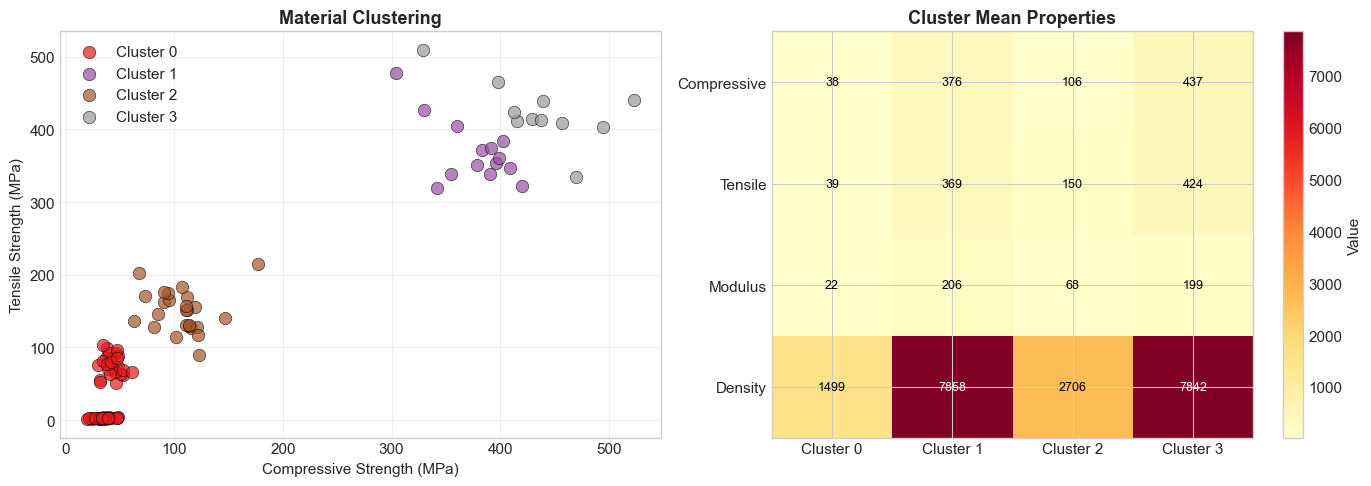


📊 Cluster Interpretation:
  - High compressive/tensile + high density → Steel
  - Low compressive/tensile + low density → Wood
  - Medium properties + high density → Aluminum
  - Low tensile + medium compressive → Concrete


In [20]:
# Load material property data
material_data = material_property_data(n_samples=100, n_materials=4, random_state=42)
X_materials = material_data['X']
y_true_materials = material_data['y_true']

print(f"🧱 {len(X_materials)} material samples")
print(f"   Features: {material_data['feature_names']}")
print(f"   True materials: {material_data['material_names']}")

# Normalize (crucial for materials with different scales!)
X_mat_norm = (X_materials - X_materials.mean(axis=0)) / X_materials.std(axis=0)

# Cluster
mat_result = kmeans(X_mat_norm, k=4, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compressive vs Tensile strength
ax = axes[0]
colors = plt.cm.Set1(np.linspace(0, 1, 4))
for k in range(4):
    mask = mat_result['labels'] == k
    ax.scatter(X_materials[mask, 0], X_materials[mask, 1], c=[colors[k]], 
              s=80, alpha=0.7, edgecolors='black', linewidths=0.5,
              label=f'Cluster {k}')
ax.set_xlabel('Compressive Strength (MPa)', fontsize=11)
ax.set_ylabel('Tensile Strength (MPa)', fontsize=11)
ax.set_title('Material Clustering', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Confusion with true labels
from sklearn.metrics import confusion_matrix as sk_confusion
try:
    from scipy.optimize import linear_sum_assignment
    
    # Find best cluster-label mapping
    cm = sk_confusion(y_true_materials, mat_result['labels'])
    row_ind, col_ind = linear_sum_assignment(-cm)
    accuracy = cm[row_ind, col_ind].sum() / len(y_true_materials)
    print(f"\n🎯 Clustering accuracy (best mapping): {accuracy:.1%}")
except ImportError:
    accuracy = None

# Cluster centers interpretation
ax = axes[1]
cluster_means = []
for k in range(4):
    mask = mat_result['labels'] == k
    cluster_means.append(X_materials[mask].mean(axis=0))

cluster_means = np.array(cluster_means)

# Heatmap-style interpretation
im = ax.imshow(cluster_means.T, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(4))
ax.set_xticklabels([f'Cluster {k}' for k in range(4)])
ax.set_yticks(range(4))
ax.set_yticklabels(['Compressive', 'Tensile', 'Modulus', 'Density'])
ax.set_title('Cluster Mean Properties', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Value')

# Add value annotations
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{cluster_means[j, i]:.0f}', ha='center', va='center', 
               fontsize=9, color='white' if cluster_means[j, i] > cluster_means.max()/2 else 'black')

plt.tight_layout()
plt.show()

print("\n📊 Cluster Interpretation:")
print("  - High compressive/tensile + high density → Steel")
print("  - Low compressive/tensile + low density → Wood")
print("  - Medium properties + high density → Aluminum") 
print("  - Low tensile + medium compressive → Concrete")

---
## 11. Summary & Key Takeaways

### K-Means Clustering
- ✅ Simple, fast, scalable
- ✅ Works well for spherical clusters
- ❌ Requires K to be specified
- ❌ Sensitive to initialization (use K-Means++)

### Hierarchical Clustering
- ✅ No need to specify K upfront
- ✅ Produces interpretable dendrograms
- ❌ Computationally expensive for large datasets
- ✅ Various linkage methods for different cluster shapes

### Choosing K
- **Elbow Method**: Look for WCSS decrease slowdown
- **Silhouette Score**: Maximize cluster cohesion/separation
- **Domain Knowledge**: Often the best guide!

### Distance Metrics
- **Euclidean**: Default, general purpose
- **Manhattan**: Robust to outliers
- **Cosine**: Direction over magnitude
- **Jaccard**: Set similarity

### Civil Engineering Applications
- Sensor behavior grouping (SHM)
- Traffic regime identification
- Material classification
- Anomaly detection
- Spatial clustering of infrastructure

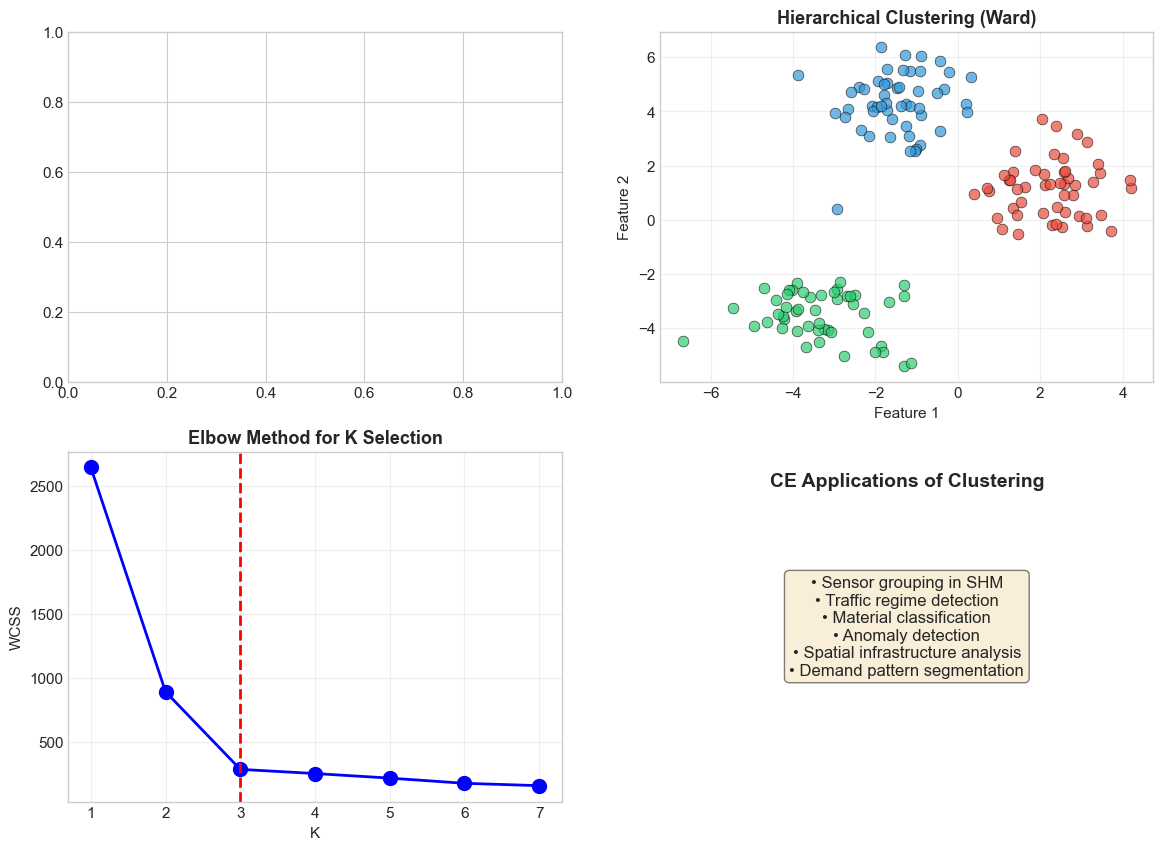

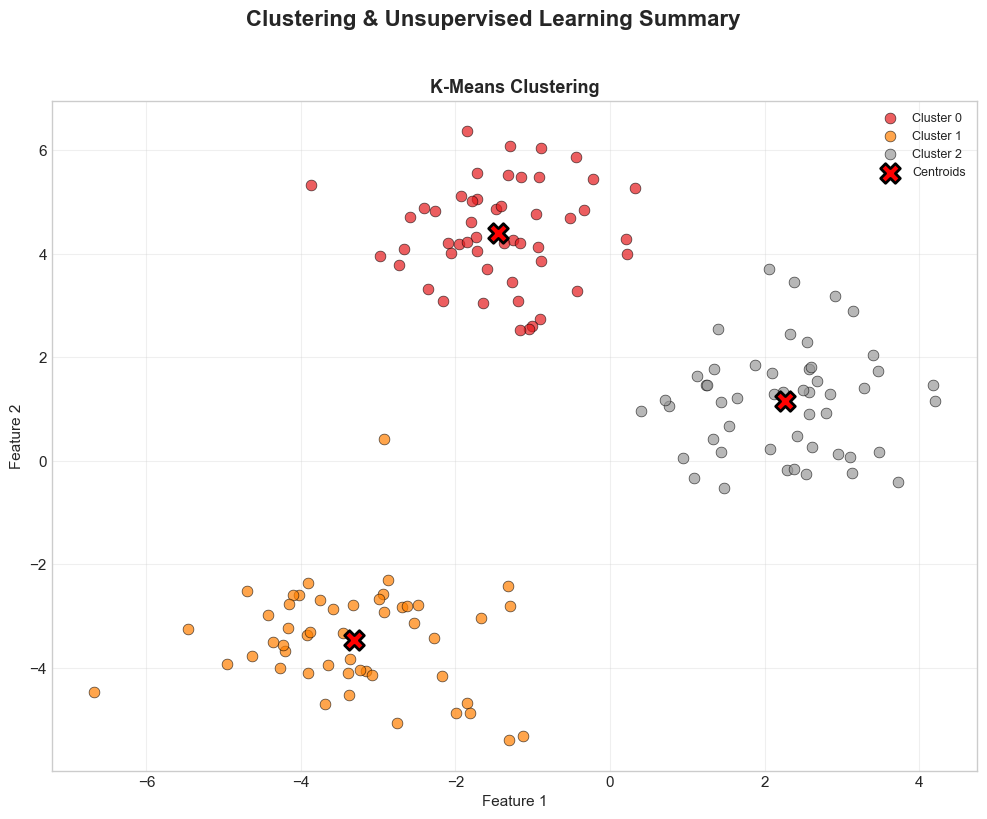


🎓 LECTURE 08 COMPLETE: Clustering & Unsupervised Learning

📚 Next Steps:
   1. Practice with the interactive widgets
   2. Apply clustering to your own CE datasets
   3. Experiment with different K values and metrics
   4. Try combining clustering with supervised learning


In [21]:
# Final summary visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# K-Means summary
ax = axes[0, 0]
X_demo = generate_blob_data(n_samples=150, n_clusters=3, random_state=42)['X']
result_demo = kmeans(X_demo, k=3, random_state=42)
plot_clusters_2d(X_demo, result_demo['labels'], result_demo['centroids'],
                 title='K-Means Clustering')

# Hierarchical summary
ax = axes[0, 1]
hier_demo = agglomerative_clustering(X_demo, n_clusters=3, method='ward')
for i, color in enumerate(['#e74c3c', '#3498db', '#2ecc71']):
    mask = hier_demo['labels'] == i
    ax.scatter(X_demo[mask, 0], X_demo[mask, 1], c=color, s=60, 
              alpha=0.7, edgecolors='black', linewidth=0.5)
ax.set_title('Hierarchical Clustering (Ward)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)

# Elbow summary
ax = axes[1, 0]
elbow_demo = elbow_method(X_demo, k_range=range(1, 8), random_state=42)
ax.plot(elbow_demo['k_values'], elbow_demo['wcss'], 'bo-', linewidth=2, markersize=10)
ax.axvline(3, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('K')
ax.set_ylabel('WCSS')
ax.set_title('Elbow Method for K Selection', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Application summary
ax = axes[1, 1]
ax.text(0.5, 0.9, 'CE Applications of Clustering', fontsize=14, fontweight='bold',
       ha='center', transform=ax.transAxes)
applications = [
    '• Sensor grouping in SHM',
    '• Traffic regime detection',
    '• Material classification',
    '• Anomaly detection',
    '• Spatial infrastructure analysis',
    '• Demand pattern segmentation'
]
ax.text(0.5, 0.5, '\n'.join(applications), fontsize=12,
       ha='center', va='center', transform=ax.transAxes,
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.axis('off')

plt.suptitle('Clustering & Unsupervised Learning Summary', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("🎓 LECTURE 08 COMPLETE: Clustering & Unsupervised Learning")
print("=" * 60)
print("\n📚 Next Steps:")
print("   1. Practice with the interactive widgets")
print("   2. Apply clustering to your own CE datasets")
print("   3. Experiment with different K values and metrics")
print("   4. Try combining clustering with supervised learning")